<a href="https://colab.research.google.com/github/Aniketyadav29/Data-Science-Tutorial/blob/main/Module_7_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K-Nearest Neighbour(KNN)**

K-Nearest Neighbour (KNN) is a supervised learning algorithm that predicts the class or value of a new data point

### What is K-Nearest Neighbors (KNN)?

K-Nearest Neighbors (KNN) is a non-parametric, lazy learning algorithm used for both classification and regression tasks. The core idea behind KNN is that similar things are near to each other. When predicting the class or value for a new data point, KNN looks at its `k` nearest neighbors (data points with the shortest distance) in the training dataset and makes a decision based on their properties.

#### How it works:

1.  **Choose a value for K**: This is the number of neighbors to consider.
2.  **Calculate Distance**: For a new data point, calculate its distance to all other data points in the training set. Common distance metrics include Euclidean distance, Manhattan distance, or Minkowski distance.
3.  **Find K Nearest Neighbors**: Select the `k` data points that have the smallest distances to the new data point.
4.  **Vote for Classification (or Average for Regression)**:
    *   **Classification**: Assign the new data point to the class that is most frequent among its `k` nearest neighbors.
    *   **Regression**: Predict the value for the new data point by taking the average (or weighted average) of the values of its `k` nearest neighbors.

Let's demonstrate a simple KNN classification with Python.

In [ ]:
import numpy as np
from collections import Counter

class KNNClassifier:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2)**2))

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        # Calculate distances from x to all training samples
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]

        # Get the k nearest neighbors (indices and labels)
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Majority vote for classification
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

# --- Demo ---

# Generate some synthetic data
X_train = np.array([
    [1, 1],
    [1.5, 2],
    [3, 4],
    [5, 7],
    [3.5, 5],
    [4, 6],
    [0.5, 0.5]
])
y_train = np.array([0, 0, 1, 1, 1, 1, 0]) # 0 for class A, 1 for class B

# New data points to predict
X_test = np.array([
    [1, 3],
    [6, 8],
    [2.5, 4.5]
])

# Initialize and train the KNN classifier
knn = KNNClassifier(k=3)
knn.fit(X_train, y_train)

# Make predictions
predictions = knn.predict(X_test)

print("Training Data (X_train):\n", X_train)
print("Training Labels (y_train):\n", y_train)
print("\nNew Data Points (X_test):\n", X_test)
print("\nPredictions for X_test:", predictions)


Training Data (X_train):
 [[1.  1. ]
 [1.5 2. ]
 [3.  4. ]
 [5.  7. ]
 [3.5 5. ]
 [4.  6. ]
 [0.5 0.5]]
Training Labels (y_train):
 [0 0 1 1 1 1 0]

New Data Points (X_test):
 [[1.  3. ]
 [6.  8. ]
 [2.5 4.5]]

Predictions for X_test: [0 1 1]


# **Workflow of KNN**

Training Dataset -> choose k -> calculate Distance -> Find K Nearest  Neighbour -> Majority Voting -> Prediction.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
data={
    "Hours":[2,3,5,6,7],
    "Attendence":[60,65,80,85,90],
    "Result":["Pass","Pass","Pass","Fail","Fail"]
}
df = pd.DataFrame(data)
X=df[["Hours","Attendence"]]
y=df["Result"]

# Prediction with n_neighbors=3
model=KNeighborsClassifier(n_neighbors=3)
model.fit(X,y)
new_data_point_3 = pd.DataFrame([[5, 75]], columns=X.columns)
prediction_3 = model.predict(new_data_point_3)
print(prediction_3[0])

# Prediction with n_neighbors=5
model=KNeighborsClassifier(n_neighbors=5)
model.fit(X,y)
new_data_point_5 = pd.DataFrame([[5, 75]], columns=X.columns)
prediction_5 = model.predict(new_data_point_5)
print(prediction_5[0])

Pass
Pass


# **Naive Bayes**



### What is Naive Bayes?

Naive Bayes is a family of probabilistic classification algorithms based on Bayes' theorem. It's called "naive" because it makes a strong (and often unrealistic) assumption that the features used for classification are conditionally independent of each other, given the class label. Despite this simplifying assumption, Naive Bayes classifiers often perform surprisingly well in many real-world applications, especially with high-dimensional data.

#### How it works (General Principle):

Bayes' Theorem states:

$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$

Where:
*   $P(A|B)$ is the posterior probability: the probability of class A given predictor B.
*   $P(B|A)$ is the likelihood: the probability of predictor B given class A.
*   $P(A)$ is the prior probability: the probability of class A.
*   $P(B)$ is the evidence: the probability of predictor B.

In the context of classification, we want to find the class $y$ that maximizes the posterior probability $P(y|X)$, where $X$ is a vector of features ($x_1, x_2, ..., x_n$).

Using Bayes' theorem, we get:

$P(y|x_1, ..., x_n) = \frac{P(x_1, ..., x_n|y) \cdot P(y)}{P(x_1, ..., x_n)}$

Due to the "naive" independence assumption, $P(x_1, ..., x_n|y)$ simplifies to $P(x_1|y) \cdot P(x_2|y) \cdot ... \cdot P(x_n|y)$.

So, the classification rule becomes:

$y = \operatorname{argmax}_y \left( P(y) \prod_{i=1}^{n} P(x_i|y) \right)$

The denominator $P(x_1, ..., x_n)$ is constant for all classes and can be ignored for classification. The algorithm calculates this for each possible class and assigns the data point to the class with the highest probability.

#### Types of Naive Bayes Classifiers:

Different Naive Bayes classifiers vary depending on the distribution assumption of $P(x_i|y)$:

*   **Gaussian Naive Bayes**: Assumes that continuous features associated with each class are distributed according to a Gaussian (normal) distribution.
*   **Multinomial Naive Bayes**: Used for discrete counts, particularly for text classification where features represent word counts or frequencies.
*   **Bernoulli Naive Bayes**: Assumes that features are binary (e.g., word presence or absence in a document).

#### Advantages:
*   Easy and fast to implement.
*   Performs well with large datasets.
*   Requires a small amount of training data to estimate the necessary parameters.
*   Highly scalable.

#### Disadvantages:
*   The strong independence assumption rarely holds true in real-world scenarios.
*   Zero-frequency problem (if a categorical variable has a category not observed in training data, the model might assign zero probability).

# **Support Vector Machine(SVM)**



### What is Support Vector Machine (SVM)?

Support Vector Machine (SVM) is a powerful, supervised machine learning algorithm used for both classification and regression tasks. However, it is primarily used for classification. The main idea behind SVM is to find a hyperplane in an N-dimensional space (N is the number of features) that distinctly classifies the data points.

#### How it works (for binary classification):

1.  **Hyperplane**: An SVM creates a decision boundary, called a hyperplane, that separates different classes of data points.
2.  **Support Vectors**: These are the data points closest to the hyperplane. They are crucial because they directly influence the position and orientation of the hyperplane. Removing them would change the position of the hyperplane.
3.  **Margin**: The distance between the hyperplane and the nearest data point from either class is called the margin. SVM aims to find a hyperplane that has the largest possible margin between the classes. A larger margin generally leads to better generalization and lower classification error on unseen data.

#### Key Concepts:

*   **Linear SVM**: When the data can be perfectly separated by a straight line (or a hyperplane in higher dimensions), the SVM is called linear.
*   **Non-linear SVM (Kernel Trick)**: Often, data points are not linearly separable. In such cases, SVM uses a technique called the "kernel trick". A kernel function transforms the input data into a higher-dimensional feature space where it becomes linearly separable. Common kernel functions include:
    *   **Polynomial Kernel**
    *   **Radial Basis Function (RBF) Kernel / Gaussian Kernel**
    *   **Sigmoid Kernel**
*   **Regularization (C parameter)**: The `C` parameter controls the trade-off between achieving a low training error and a large margin. A small `C` creates a larger margin but may lead to more misclassifications. A large `C` aims for fewer misclassifications, potentially leading to a smaller margin.

#### Advantages:
*   Effective in high-dimensional spaces.
*   Effective in cases where the number of dimensions is greater than the number of samples.
*   Uses a subset of training points in the decision function (support vectors), making it memory efficient.
*   Versatile: different kernel functions can be specified for the decision function.

#### Disadvantages:
*   If the number of features is much greater than the number of samples, avoiding over-fitting can be tricky.
*   SVMs don’t directly provide probability estimates; these are calculated using an expensive five-fold cross-validation.
*   Less effective on noisy datasets with overlapping classes.

Let's see a simple example of SVM classification using `scikit-learn`.

Accuracy of SVM classifier with linear kernel: 0.80


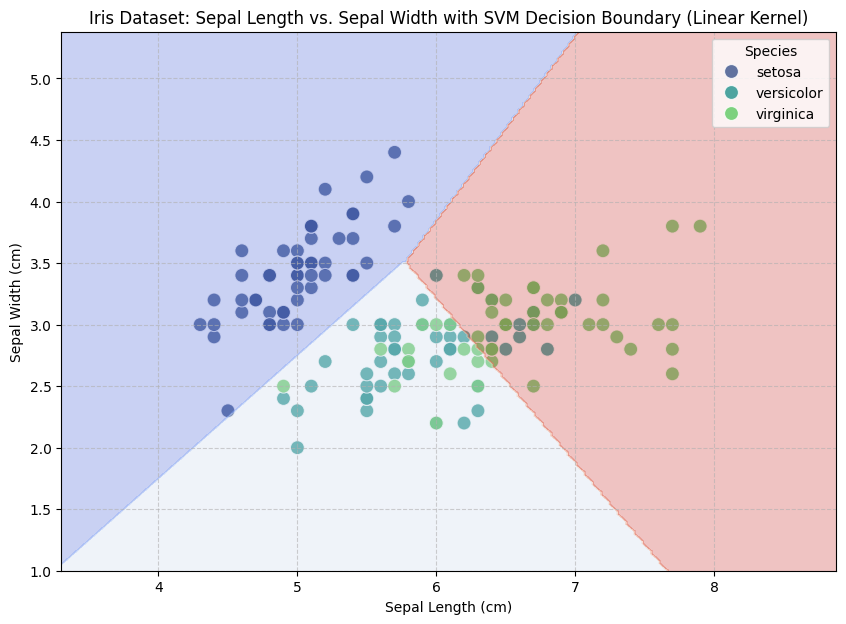

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # We take only the first two features (sepal length and sepal width)
y = iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create an SVM classifier with a linear kernel
svm_model = SVC(kernel='linear', C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of SVM classifier with linear kernel: {accuracy:.2f}")

# --- Visualization ---

# Create a DataFrame for easier plotting
df_plot = pd.DataFrame(X, columns=['sepal_length', 'sepal_width'])
df_plot['species'] = iris.target_names[y]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='sepal_length',
    y='sepal_width',
    hue='species',
    data=df_plot,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Iris Dataset: Sepal Length vs. Sepal Width with SVM Decision Boundary (Linear Kernel)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')

# Plotting the decision boundary
ax = plt.gca()
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


This example uses the well-known Iris dataset to classify flowers based on sepal length and sepal width. It demonstrates how to initialize, train, and evaluate a linear SVM classifier and visualizes its decision boundary.

# **Cluster**



### What is a Cluster?

In machine learning and data analysis, a **cluster** refers to a collection of data points that are grouped together because they share similar characteristics or properties. These groups are formed through a process called **clustering**, which is an unsupervised learning technique.

The goal of clustering is to partition a dataset into subsets (clusters) such that data points within the same cluster are more similar to each other than to those in other clusters. Unlike classification, clustering does not rely on predefined labels; instead, it discovers inherent structures or patterns in the data.

#### Key Characteristics of Clusters:

*   **Homogeneity within a cluster**: Data points within a single cluster are similar to each other.
*   **Heterogeneity between clusters**: Data points in different clusters are dissimilar from each other.

#### Common Applications:

*   **Customer Segmentation**: Grouping customers with similar buying behaviors.
*   **Document Analysis**: Organizing documents into topics.
*   **Image Segmentation**: Dividing an image into regions of similar pixels.
*   **Anomaly Detection**: Identifying outliers that do not belong to any cluster.
*   **Biological Data Analysis**: Grouping genes or proteins with similar functions.

### Types of Clustering :

*   **Centroid-Based (e.g., K-Means)**: Groups data around central points (centroids), ideal for compact, spherical clusters.
*   **Density-Based (e.g., DBSCAN)**: Identifies clusters as dense regions, capable of finding arbitrary shapes and handling noise.
*   **Distribution-Based (e.g., GMM)**: Assumes data points belong to probability distributions, providing probabilistic assignments.
*   **Hierarchical (e.g., Agglomerative/Divisive)**: Builds a tree-like hierarchy of clusters, useful for visualizing nested structures.
*   **Grid-Based**: Divides data space into a grid for efficient clustering, often used for high-dimensional data.

### Clustering Workflow (with Arrows)

Let's visualize the typical workflow for a clustering analysis:

**1. Data Preparation**
   *   Clean, select/extract features, scale data.
   ⬇️

**2. Choose Clustering Algorithm**
   *   Select based on data type, cluster shape, and resources.
   ⬇️

**3. Determine Optimal Parameters**
   *   Find best 'k' (for K-Means) or other algorithm-specific parameters.
   ⬇️

**4. Apply Clustering Algorithm**
   *   Run the chosen algorithm on the prepared data.
   ⬇️

**5. Evaluate Cluster Results**
   *   Assess cluster quality using internal or external metrics.
   ⬇️

**6. Interpret & Validate Clusters**
   *   Understand cluster characteristics and ensure their practical significance.

### Hierarchical Clustering (in Short)

**Hierarchical Clustering** is a type of clustering algorithm that builds a hierarchy of clusters. It can be either **agglomerative** (bottom-up, starting with individual data points and merging them into clusters) or **divisive** (top-down, starting with one large cluster and splitting it into smaller ones). The result is often visualized as a **dendrogram**, a tree-like diagram that shows the sequence of merges or splits.

### Workflow Chart for Hierarchical Clustering

**Agglomerative (Bottom-Up) Workflow:**

1.  **Start:** Each data point is its own cluster.

    ⬇️
2.  **Calculate Proximity:** Compute distances between all pairs of clusters (initially, individual points).

    ⬇️

3.  **Merge:** Merge the two closest clusters.

    ⬇️
4.  **Update Proximity:** Recalculate distances to the new cluster.

    ⬇️
5.  **Repeat:** Go to step 3 until only one cluster remains (or a desired number of clusters is reached).

    ⬇️
6.  **Result:** A Dendrogram showing the hierarchy of mergers.

**Divisive (Top-Down) Workflow:**

1.  **Start:** All data points in one large cluster.

    ⬇️
2.  **Split:** Divide the cluster into two sub-clusters (e.g., using K-Means).

    ⬇️
3.  **Repeat:** Recursively split sub-clusters until each data point is its own cluster (or a desired number of clusters is reached).

    ⬇️
4.  **Result:** A Dendrogram showing the hierarchy of splits.

    Income  Spending  Cluster
0       15        39        0
1       16        42        0
2       17        35        0
3       18        45        0
4       20        40        0
5       22        38        0
6       25        50        0
7       27        48        0
8       30        52        0
9       35        49        0
10      60        80        1
11      62        85        1
12      65        78        1
13      67        82        1
14      70        90        1
15      72        88        1
16      75        92        1
17      78        95        1
18      80        91        1
19      85        94        1
Centroids:
[[22.5 43.8]
 [71.4 87.5]]


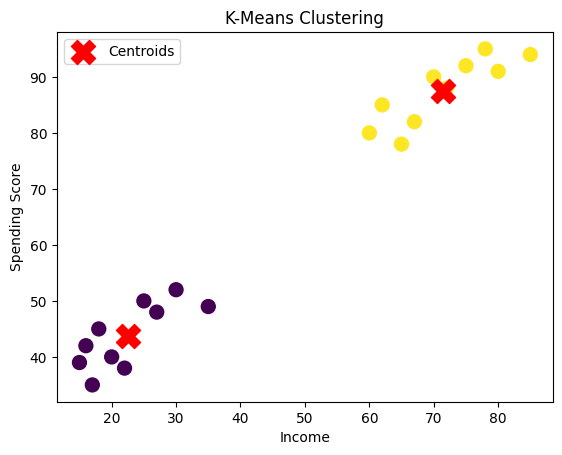

New Customer Cluster: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Dataset
data = {
    "Income": [15,16,17,18,20,22,25,27,30,35,
               60,62,65,67,70,72,75,78,80,85],

    "Spending": [39,42,35,45,40,38,50,48,52,49,
                 80,85,78,82,90,88,92,95,91,94]
}

df = pd.DataFrame(data)

# Features
X = df[["Income","Spending"]]

# Create Model
model = KMeans(
    n_clusters=2,
    random_state=42
)

# Train Model
model.fit(X)

# Predict Clusters
clusters = model.predict(X)

# Add Cluster Column
df["Cluster"] = clusters

print(df)

# Cluster Centers
print("Centroids:")
print(model.cluster_centers_)

# Visualization
plt.scatter(
    df["Income"],
    df["Spending"],
    c=df["Cluster"],
    cmap="viridis",
    s=100
)

plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=300,
    label="Centroids"
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

# New Prediction
new_customer = [[68,86]]
prediction = model.predict(new_customer)

print("New Customer Cluster:", prediction)